<a href="https://colab.research.google.com/github/soroushmirzaei/computer-vision-projects/blob/main/google-recaptcha-images-classification/google-recaptcha-images-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import requirements libraries
import os
import shutil
import zipfile

#import mathematics statics libraries
import numpy as np
import pandas as pd

#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import machine learning deep learning libraries
import tensorflow as tf
from tensorflow import keras


In [2]:
#make kaggle json file
kaggle_json = {
    "username":"kaggle-api-token-username",
    "key":"kaggle-api-token-key"
}
pd.Series(kaggle_json).to_json('kaggle.json')

#install kaggle libraries
!pip install -q kaggle

#setup kaggle libraries
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


In [3]:
#download kaggle dataset
!kaggle datasets download mikhailma/test-dataset


 99% 389M/393M [00:02<00:00, 126MB/s]
100% 393M/393M [00:02<00:00, 143MB/s]


In [4]:
#unzip file
def unzip(file_name, type_file = 'zip'):
    cur_dir = os.getcwd()
    file_path = os.path.join(cur_dir, f'{file_name}.{type_file}')
    file = zipfile.ZipFile(file_path)
    file.extractall(os.path.join(cur_dir, file_name))
    file.close()


In [5]:
unzip('test-dataset')


In [6]:
#remove file with zero size
def remove_file_zero(dir_path):
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if os.path.getsize(os.path.join(root, file)) == 0:
                os.remove(os.path.join(root, file))


In [7]:
remove_file_zero('test-dataset/Google_Recaptcha_V2_Images_Dataset/images')


In [8]:
#romove other file type
def remove_type(dir_path):
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.split('.')[-1] not in ['jpg', 'jpeg', 'bmp', 'png', 'gif']:
                os.remove(os.path.join(root, file))


In [9]:
remove_type('test-dataset/Google_Recaptcha_V2_Images_Dataset/images')


In [10]:
#define training validation set
Height = 300
Width = 300

train_gen = keras.preprocessing.image.ImageDataGenerator(rescale = 1/255, validation_split = 0.1,
                                                         horizontal_flip = True)
train_data = train_gen.flow_from_directory('/content/test-dataset/Google_Recaptcha_V2_Images_Dataset/images',
                                           target_size = (Height, Width), batch_size = 32,
                                           color_mode = 'rgb', class_mode = 'sparse', seed = 0, subset = 'training')

valid_gen = keras.preprocessing.image.ImageDataGenerator(rescale = 1/255, validation_split = 0.1)
valid_data = valid_gen.flow_from_directory('/content/test-dataset/Google_Recaptcha_V2_Images_Dataset/images',
                                         target_size = (Height, Width), batch_size = 32,
                                         color_mode = 'rgb', class_mode = 'sparse', seed = 0, subset = 'validation')


Found 10560 images belonging to 12 classes.
Found 1170 images belonging to 12 classes.


In [ ]:
#define pretrained model
pretrained_model = keras.applications.ResNet101V2(input_shape = (Height, Width, 3), include_top = False, pooling = 'avg')

for layer in pretrained_model.layers:
    layer.trainable = False


In [12]:
#create model function
def create_model(#dense layer configuration
                 dense_layers_num, dense_units, dense_dropout_ratio,
                 #output layer configuration
                 out_units = train_data.num_classes,
                 #activations configuration
                 dense_activation = 'relu', out_activation = 'softmax',

                 #input shape
                 inp_shape = (Height, Width, 3),

                 #compiling Configuration
                 compile_optimizer = 'adam', compile_loss ='sparse_categorical_crossentropy' ,
                 compile_metric = ['accuracy'],
                 
                 #dense layers
                 dense_head = True,  batch_norm_dense = True, dropout_dense = True):

    #define input layer
    input = keras.Input(inp_shape)

    #define transfer learning layer
    out = pretrained_model(input)

    #convert dimensionality
    out = keras.layers.Flatten()(out)

    #feature extracter dropout layer 
    out = keras.layers.Dropout(0.3)(out)

    #define dense layers
    if dense_head:
        for i in range(dense_layers_num):
            if batch_norm_dense:
                out = keras.layers.BatchNormalization()(out)
            out = keras.layers.Dense(units = dense_units[i], activation = dense_activation,
                                     kernel_initializer = keras.initializers.HeNormal())(out)
            if dropout_dense:
                out = keras.layers.Dropout(dense_dropout_ratio[i])(out)

    #define output layers
    output = keras.layers.Dense(units = out_units, activation = out_activation)(out)

    model = keras.models.Model(input, output)

    #define model compile
    model.compile(optimizer = compile_optimizer,
                  loss = compile_loss,
                  metrics = compile_metric)

    return model


In [13]:
#define custom callbacks
class callback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs = None):
        self.model.save('/content/google-recaptcha-images-classification-model.h5')
        

In [14]:
#create model
model = create_model(#dense layer configuration
                     dense_layers_num = int(2), dense_units = list([128,128]), dense_dropout_ratio = list([0.3,0.3]), 
                     #output layer configuration
                     out_units = train_data.num_classes,
                     #activations configuration
                     dense_activation = 'relu', out_activation = 'softmax',
                     
                     #input shape
                     inp_shape = (Height, Width, 3),
                     
                     #compiling Configuration
                     compile_optimizer = 'adam', compile_loss = 'sparse_categorical_crossentropy' ,
                     compile_metric = ['accuracy'],
                     
                     #dense layers
                     dense_head = True,  batch_norm_dense = True, dropout_dense = False)


In [ ]:
#fit model for training
model.fit(train_data, validation_data = valid_data, epochs = 100, verbose = 0,
          callbacks = [keras.callbacks.EarlyStopping(patience = 5, restore_best_weights = True, monitor = 'val_loss'),
                       keras.callbacks.CSVLogger('log.csv'), callback()])


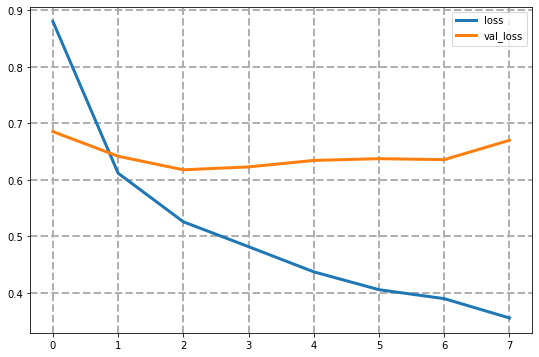

In [16]:
#plot history and logger
pd.read_csv('/content/log.csv')[['loss', 'val_loss']].plot(figsize = (9, 6), linewidth = 3)
plt.grid(linestyle = '--', linewidth = 2)
plt.show()


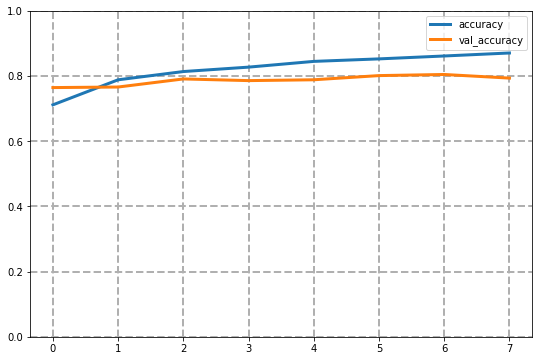

In [17]:
#plot history and logger
pd.read_csv('/content/log.csv')[['accuracy', 'val_accuracy']].plot(figsize = (9, 6), linewidth = 3)
plt.grid(linestyle = '--', linewidth = 2)
plt.ylim(0,1)
plt.show()


In [18]:
#model evaluation
train_set_eval = model.evaluate(train_data, verbose = 0, return_dict = True)
valid_set_eval = model.evaluate(valid_data, verbose = 0, return_dict = True)

print('Training Set Evaluation:')
for item in train_set_eval:
    print(f'\t{item.title()}:\t{round(train_set_eval[item],4)}', end = '\t')
print()
print('Validation Set Evaluation:')
for item in valid_set_eval:
    print(f'\t{item.title()}:\t{round(valid_set_eval[item],4)}', end = '\t')


Training Set Evaluation:
	Loss:	0.3398		Accuracy:	0.8816	
Validation Set Evaluation:
	Loss:	0.6178		Accuracy:	0.7906	

In [19]:
#make list of images for random prediction
def image_file(dir_path):
    image_list = list()
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            image_list.append(os.path.join(root, file))
    return image_list


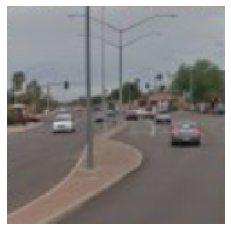

In [127]:
#draw random image
img = valid_data.next()[0][np.random.choice(32, 1)]
image = img

plt.axis('off')
plt.imshow(img[0])
plt.show()


In [128]:
#prediction for random image
pd.DataFrame(model.predict(img), columns = train_data.class_indices).round(5)


,Bicycle,Bridge,Bus,Car,Chimney,Crosswalk,Hydrant,Motorcycle,Other,Palm,Stair,Traffic Light
0,0.00018,0.00013,0.00423,0.68062,0.00012,0.13152,0.00006,0.0006,0.02198,0.00435,0.00124,0.155


In [22]:
#save model
model.save('/content/google-recaptcha-images-classification-model.h5')
